<a href="https://colab.research.google.com/github/Kari-2005/carisurg-portfolio/blob/main/Assignment_3/Assignment_3_Data_Visulatization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CARISURG WEEK 0 - ASSIGNMENT 3 - Data Visualization
## Submitted by Ansarah Mohammed

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/CARISURG/Week0/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


In [65]:
# ── FIRST PLOT: MAP vs GCS levels ────────────────────────────────

# 1. What is the clinical question this plot answers?
#    This plot is trying to show if patients with different GCS levels have different MAP values.
#    GCS tells us how awake or responsive a patient is, while MAP tells us if enough blood is
#    being pushed around the body. In simple terms, I want to see if patients who are less alert
#    also have blood pressure values that may be more concerning.

# 2. What type of plot is appropriate?
#    A box plot is appropriate because MAP is a number, and GCS can be placed into groups such
#    as Severe, Moderate, Mild, and Normal. The box plot makes it easy to compare the middle value,
#    the spread of the values, and any unusual values in each group.

# 3. What reference lines or annotations would add clinical meaning?
#    I added a line at MAP = 65 mmHg because values below this may mean the body is not getting
#    enough blood flow. I also added a line at MAP = 110 mmHg because very high MAP values can
#    also be concerning. These lines help make the graph easier to understand clinically.

/tmp/ipykernel_3502/1435556310.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


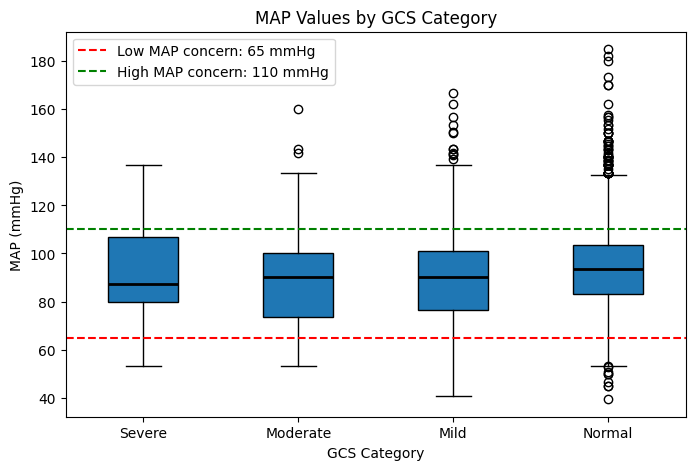

Saved: my_plot_1.png


In [66]:
# My code for the box plot starts here:

# Creating GCS categories so the graph is easier to understand
# GCS tells us how awake or responsive a patient is.
# Lower GCS means the patient is less alert.

def classify_gcs(gcs):
    if gcs <= 8:
        return 'Severe'
    elif gcs <= 12:
        return 'Moderate'
    elif gcs <= 14:
        return 'Mild'
    elif gcs == 15:
        return 'Normal'
    else:
        return np.nan

df['GCS_Category'] = df['GCS'].apply(classify_gcs)

df[['GCS', 'GCS_Category']].head()

# Checking how many patients fall into each GCS category

df['GCS_Category'].value_counts()

# Setting the order for the categories on the graph

gcs_order = ['Severe', 'Moderate', 'Mild', 'Normal']

# Collecting MAP values for each GCS category

map_values_by_gcs = []

for category in gcs_order:
    values = df[df['GCS_Category'] == category]['MAP'].dropna()
    map_values_by_gcs.append(values)

# Creating a box plot to compare MAP values across GCS categories

plt.figure(figsize=(8, 5))

plt.boxplot(
    map_values_by_gcs,
    labels=gcs_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

# Adding clinically meaningful reference lines
# Red line = low MAP concern
# Green line = high MAP concern

plt.axhline(y=65, linestyle='--', color='red', linewidth=1.5, label='Low MAP concern: 65 mmHg')
plt.axhline(y=110, linestyle='--', color='green', linewidth=1.5, label='High MAP concern: 110 mmHg')

# Adding title and labels
plt.title('MAP Values by GCS Category')
plt.xlabel('GCS Category')
plt.ylabel('MAP (mmHg)')

# Adding legend
plt.legend()

# Saving and showing the plot
plt.savefig('my_plot_1.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: my_plot_1.png")

# The circles shown on the box plot are outliers.
# This means they are MAP values that are much higher or lower than most of the values in that GCS category.
# In this clinical dataset, I would not automatically treat these as errors because very high or very low MAP values
# may represent real patients who need medical attention.
# The reference lines at 65 mmHg and 110 mmHg help show which values may be clinically concerning.

In [67]:
# ── SECOND PLOT: MAP Distribution by Gender ────────────────────────────────
#
# 1. What is the clinical question this plot answers?
#    This plot is trying to show if male and female patients have different MAP distributions.
#    MAP tells us if enough blood is being pushed around the body. In simple terms, I want to
#    see if one gender group has more patients with MAP values that are too low or too high.
#
# 2. What type of plot is appropriate?
#    A histogram is appropriate because MAP is a number, and I want to see how often different
#    MAP values appear. By separating the histogram by gender, I can compare the shape and spread
#    of MAP values for male and female patients.
#
# 3. What reference lines or annotations would add clinical meaning?
#    A line at MAP = 65 mmHg is useful because values below this may mean the body is not getting
#    enough blood flow. A line at MAP = 110 mmHg is also useful because very high MAP values may
#    need attention.

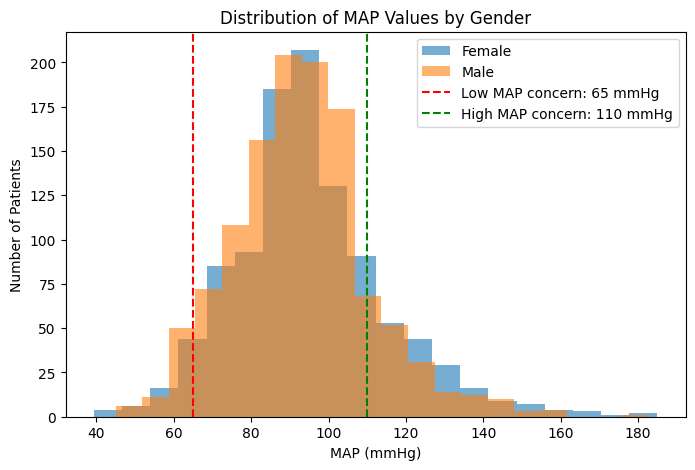

Saved: my_plot_2.png


In [68]:
# My code for the histogram plot starts here:

# Creating a labelled gender column so the plot is easier to understand
# In this dataset:
# 0 = Female
# 1 = Male

df['Gender_Label'] = df['Gender'].map({
    0: 'Female',
    1: 'Male'
})

# Checking the gender labels
df[['Gender', 'Gender_Label']].head()

# Checking how many patients are in each gender group

df['Gender_Label'].value_counts()

# Separating MAP values for female and male patients

female_map = df[df['Gender_Label'] == 'Female']['MAP']
male_map = df[df['Gender_Label'] == 'Male']['MAP']

# Creating a histogram to compare MAP distribution by gender

plt.figure(figsize=(8, 5))

plt.hist(female_map, bins=20, alpha=0.6, label='Female')
plt.hist(male_map, bins=20, alpha=0.6, label='Male')

# Adding clinically meaningful reference lines
# Red line = low MAP concern
# Green line = high MAP concern

plt.axvline(x=65, linestyle='--', color='red', linewidth=1.5, label='Low MAP concern: 65 mmHg')
plt.axvline(x=110, linestyle='--', color='green', linewidth=1.5, label='High MAP concern: 110 mmHg')

# Adding title and axis labels

plt.title('Distribution of MAP Values by Gender')
plt.xlabel('MAP (mmHg)')
plt.ylabel('Number of Patients')

# Adding legend

plt.legend()

# Saving and showing the plot

plt.savefig('my_plot_2.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: my_plot_2.png")

# This histogram compares MAP values between male and female patients.
# Each bar shows how many patients fall within a certain MAP range.
# The red dotted line shows MAP = 65 mmHg, where values below this may be too low.
# The green dotted line shows MAP = 110 mmHg, where values above this may be high.
# This plot is useful because MAP is a clinical value, so very low or very high values
# should not be ignored in an emergency triage setting.

In [69]:
# ── THIRD PLOT: Age vs MAP ────────────────────────────────────────────────
#
# 1. What is the clinical question this plot answers?
#    This plot is trying to show whether patient age has any relationship with MAP.
#    Age tells us how old the patient is, while MAP tells us if enough blood is
#    being pushed around the body. In simple words, I want to see if older or
#    younger patients tend to have different MAP values.
#
# 2. What type of plot is appropriate?
#    A scatter plot is appropriate because both Age and MAP are numerical values.
#    This makes it easier to see whether there is any visible relationship or trend
#    between the patient's age and MAP.
#
# 3. What reference lines or annotations would add clinical meaning?
#    A horizontal line at MAP = 65 mmHg is useful because values below this may
#    suggest poor blood flow. A second horizontal line at MAP = 110 mmHg is useful
#    because higher MAP values may also need attention.

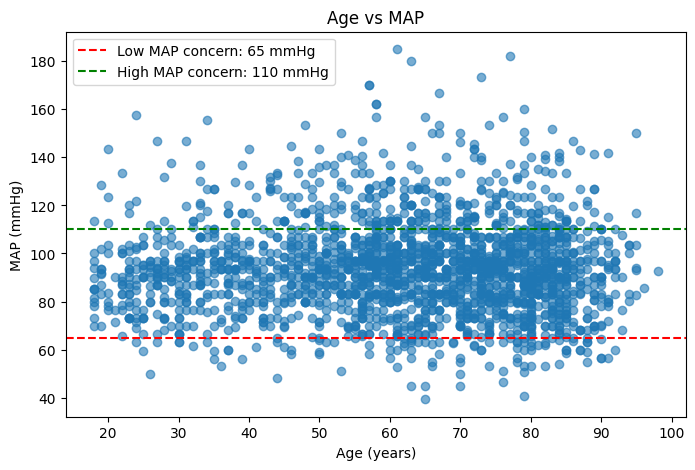

Saved: my_plot_3.png


In [70]:
# My code for the scatter plot starts here:

# Creating a scatter plot of Age vs MAP

plt.figure(figsize=(8, 5))

plt.scatter(df['Age'], df['MAP'], alpha=0.6)

# Adding clinically meaningful reference lines
plt.axhline(y=65, linestyle='--', color='red', linewidth=1.5, label='Low MAP concern: 65 mmHg')
plt.axhline(y=110, linestyle='--', color='green', linewidth=1.5, label='High MAP concern: 110 mmHg')

# Adding title and axis labels
plt.title('Age vs MAP')
plt.xlabel('Age (years)')
plt.ylabel('MAP (mmHg)')

# Adding legend
plt.legend()

# Saving and showing the plot
plt.savefig('my_plot_3.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: my_plot_3.png")

# This scatter plot compares patient age and MAP.
# Each dot represents one patient.
# If a dot is farther to the right, it means the patient is older.
# If a dot is higher up, it means the patient has a higher MAP.
# The red dashed line shows low MAP values that may be concerning,
# while the green dashed line shows higher MAP values.
# This plot is useful because it helps show whether age may have any
# visible relationship with MAP in the emergency triage dataset.